In [1]:
import os
print(os.getcwd())

C:\Users\ahmad\JupyterNotebooks\HeartDisease


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.csv')

In [4]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [54]:
df.columns

Index(['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol',
       'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina',
       'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium',
       'Heart Disease'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [6]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


Visualization Stage

<Axes: xlabel='Heart Disease', ylabel='count'>

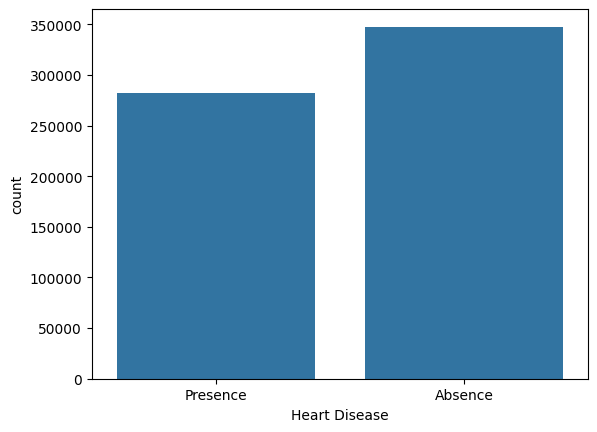

In [7]:
sns.countplot(data=df, x='Heart Disease')

<Axes: xlabel='Chest pain type', ylabel='count'>

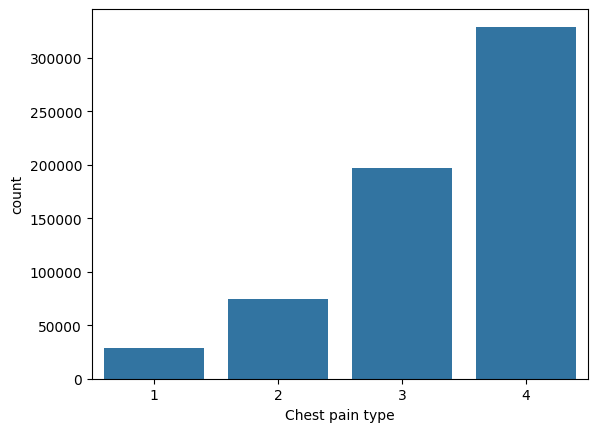

In [8]:
sns.countplot(data=df, x='Chest pain type')

In [9]:
df_corr = df.drop('id',axis=1).copy()
df_corr['Heart Disease'] = df_corr['Heart Disease'].map({'Presence':1, 'Absence':0})

<Axes: >

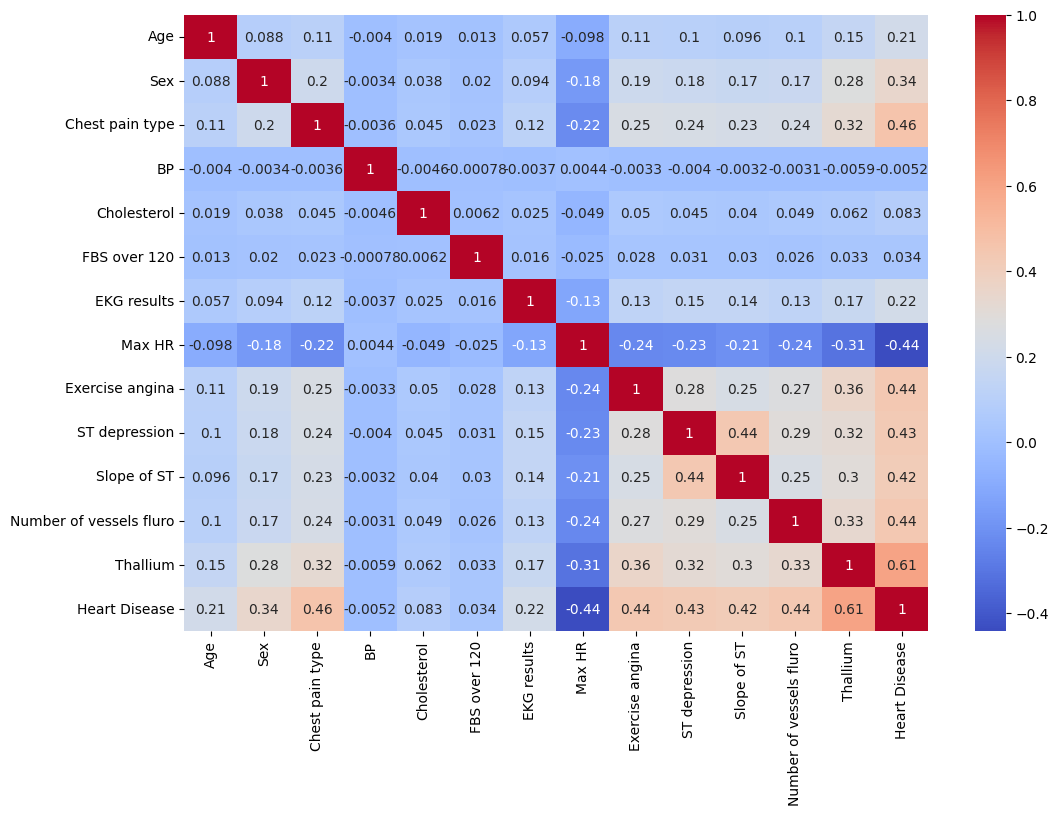

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df_corr.corr(), annot= True, cmap='coolwarm')

Text(0.5, 1.0, 'Distribution of Blood Pressure by Heart Disease Status')

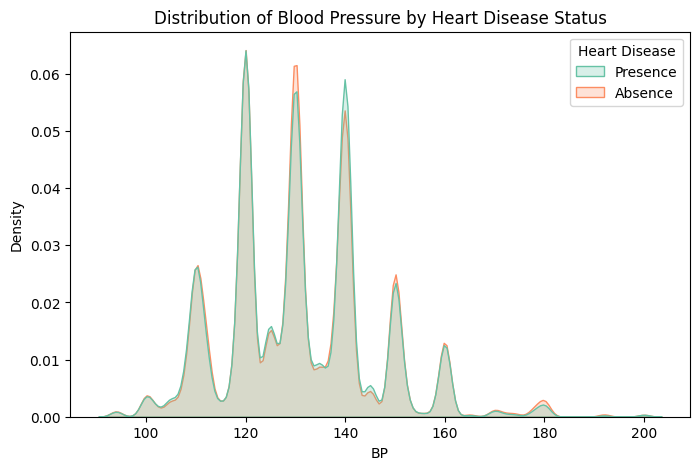

In [11]:
plt.figure(figsize=(8, 5))
# Plot the distribution of BP for healthy patients vs sick patients
sns.kdeplot(data=df, x='BP', hue='Heart Disease', fill=True, common_norm=False, palette='Set2')
plt.title('Distribution of Blood Pressure by Heart Disease Status')

Preprocessing Stage

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})

In [14]:
X = df.drop(columns=['id', 'Heart Disease'])
y = df['Heart Disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Training Stage

In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=12,
    device='cuda', 
    random_state=42
)

In [16]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('model', xgb_model)
])

pipeline.fit(X_train, y_train)

predictions = pipeline.predict(X_test)

print("Pipeline training and prediction complete!")

Pipeline training and prediction complete!


D:\Python313\Lib\site-packages\xgboost\core.py:729: UserWarning: [22:01:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [17]:
# from sklearn.model_selection import RandomizedSearchCV

# # 1. Define the grid of parameters you want to test
# # Notice the 'model__' prefix so the pipeline knows these are for the RandomForest
# param_grid = {
#     'model__n_estimators': [100, 200, 300],
#     'model__max_depth': [10, 20, 30, None],
#     'model__min_samples_split': [2, 5, 10, 20],
#     'model__min_samples_leaf': [1, 2, 5, 10],
#     'model__max_features': ['sqrt', 'log2']
# }

# # 2. Set up RandomizedSearchCV
# random_search = RandomizedSearchCV(
#     estimator=pipeline,            # We pass the ENTIRE pipeline here
#     param_distributions=param_grid, 
#     n_iter=10,                     # Try 10 random combinations (increase this later if you have time)
#     cv=3,                          # 3-Fold Cross-Validation to ensure the results are robust
#     scoring='roc_auc',              # We optimize for Recall to catch as many sick patients as possible!
#     n_jobs=-1,                     # Use all CPU cores to make it run as fast as possible
#     verbose=2,                     # Prints out text so you can see its progress
#     random_state=42
# )

# # 3. Run the search on the training data
# print("Starting the hyperparameter search... this might take a few minutes!")
# random_search.fit(X_train, y_train)

# # 4. Print the winning combination!
# print("\nSearch Complete!")
# print("Best Parameters found:")
# for param, value in random_search.best_params_.items():
#     print(f" - {param}: {value}")
    
# print(f"\nBest Cross-Validated Recall Score: {random_search.best_score_:.4f}")

Classification Report:

              precision    recall  f1-score   support

 Absence (0)       0.89      0.90      0.89     69509
Presence (1)       0.87      0.86      0.86     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



<Axes: >

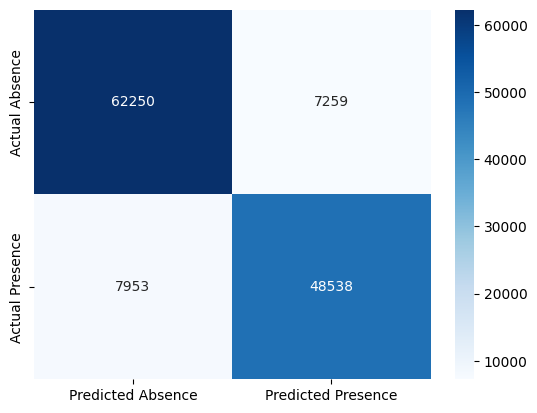

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

report = classification_report(y_test, predictions, target_names=['Absence (0)', 'Presence (1)'])
print("Classification Report:\n")
print(report)

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Absence', 'Predicted Presence'],
            yticklabels=['Actual Absence', 'Actual Presence'])

Test set

In [19]:
df_test = pd.read_csv('test.csv')

In [20]:
df_test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [21]:
test_ID = df_test['id']
df_test.drop('id', axis=1, inplace=True)

In [22]:
test_pred = pipeline.predict_proba(df_test)[:, 1]

In [23]:
submission = pd.DataFrame({
    'id': test_ID,
    'Heart Disease': test_pred
})

In [24]:
submission.head()

,id,Heart Disease
0,630000,0.986642
1,630001,0.002961
2,630002,0.997504
3,630003,0.008344
4,630004,0.081269


In [25]:
submission.to_csv('submission.csv', index=False)

In [26]:
submission.shape

(270000, 2)

Doing some Feature Engineering:

In [27]:
# 1. Update our Feature Engineering Function
def engineer_features_v2(data):
    df_new = data.copy()
    
    # -- Previous Features --
    df_new['HR_Deficit'] = (220 - df_new['Age']) - df_new['Max HR']
    df_new['Risk_Score'] = (df_new['BP'] > 130).astype(int) + \
                           (df_new['Cholesterol'] > 240).astype(int) + \
                           (df_new['Chest pain type'] == 4).astype(int)
    df_new['BP_to_Age_Ratio'] = df_new['BP'] / df_new['Age']
    
    # -- NEW: Blood Pressure Features --
    # Clinical Categories (0: Normal < 120, 1: Elevated 120-129, 2: High >= 130)
    bp_conditions = [
        (df_new['BP'] < 120),
        (df_new['BP'] >= 120) & (df_new['BP'] < 130),
        (df_new['BP'] >= 130)
    ]
    df_new['BP_Category'] = np.select(bp_conditions, [0, 1, 2], default=0)
    
    return df_new

In [40]:
# 2. Apply the new function to Train and Unseen (Kaggle) sets
X_train_v2 = engineer_features_v2(X_train)
X_test_v2 = engineer_features_v2(X_test)
X_unseen_v2 = engineer_features_v2(df_test)

In [41]:
# 3. Setup XGBoost and Pipeline
xgb_model_v2 = XGBClassifier(
    device='cuda',           # Still using your RTX 3060!
    eval_metric='auc',
    random_state=42
)

pipeline_v2 = Pipeline(steps=[
    ('scaler', StandardScaler()), 
    ('model', xgb_model_v2)
])

In [42]:
# 4. Hyperparameter Search

from sklearn.model_selection import RandomizedSearchCV
param_grid_v2 = {
    'model__n_estimators': [200, 500],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0] # Added subsample to help prevent overfitting the new features
}

random_search_v2 = RandomizedSearchCV(
    estimator=pipeline_v2,
    param_distributions=param_grid_v2, 
    n_iter=10,                     
    cv=5,                          
    scoring='roc_auc',             
    verbose=1,                     
    random_state=42
)


In [43]:
# 5. Train the Model
print("Training XGBoost on v2 engineered features...")
random_search_v2.fit(X_train_v2, y_train)

print(f"\nBest local ROC-AUC Score: {random_search_v2.best_score_:.4f}")

Training XGBoost on v2 engineered features...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best local ROC-AUC Score: 0.9549


In [46]:
from sklearn.model_selection import StratifiedKFold

# 1. Setup 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_test_preds = []

# 2. Use your best parameters from the previous search
best_xgb = random_search_v2.best_estimator_

# 3. The Loop: Train 5 models and save predictions
print("Running the 5-Fold Final Push...")
for i, (train_idx, val_idx) in enumerate(skf.split(X_train_v2, y_train)):
    print(f"Training Fold {i+1}...")
    
    # Split the data
    X_fold_train = X_train_v2.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    
    # Clone and Fit the model
    best_xgb.fit(X_fold_train, y_fold_train)
    
    # Predict on the KAGGLE test data
    fold_preds = best_xgb.predict_proba(X_unseen_v2)[:, 1]
    final_test_preds.append(fold_preds)

# 4. Average the 5 predictions
averaged_preds = np.mean(final_test_preds, axis=0)

# 5. Save the winning submission
submission_final = pd.DataFrame({'id': test_ID, 'Heart Disease': averaged_preds})
submission_final.to_csv('submission_cv5_averaged.csv', index=False)
print("Finished! Upload 'submission_cv5_averaged.csv' and check the rank!")

Running the 5-Fold Final Push...
Training Fold 1...
Training Fold 2...
Training Fold 3...
Training Fold 4...
Training Fold 5...
Finished! Upload 'submission_cv5_averaged.csv' and check the rank!


In [47]:
from catboost import CatBoostClassifier

# 1. Initialize CatBoost tailored for your RTX 3060
# CatBoost is incredibly fast on GPUs, so we can give it 1000 trees right away
cat_model = CatBoostClassifier(
    iterations=1000,          # Number of trees
    learning_rate=0.05,       # How aggressive it learns
    depth=6,                  # Tree depth
    eval_metric='AUC',        # The exact Kaggle metric!
    task_type='GPU',          # Magic word to use the RTX 3060
    random_seed=42,
    verbose=100               # Only print every 100 trees so it doesn't spam your notebook
)

# 2. Train CatBoost on your engineered data
print("Training CatBoost on the RTX 3060...")
cat_model.fit(X_train_v2, y_train)

# 3. Get CatBoost's Probabilities on the Kaggle Test Set
print("\nGenerating CatBoost probabilities...")
cat_preds = cat_model.predict_proba(X_unseen_v2)[:, 1]

# 4. THE MAGIC: Ensembling!
# We take your 'averaged_preds' from the 5-Fold XGBoost and blend them with CatBoost
print("Blending XGBoost and CatBoost together...")

# A simple 50/50 average is the best place to start
final_ensemble_preds = (averaged_preds + cat_preds) / 2

# 5. Create the Ultimate Submission File
submission_ensemble = pd.DataFrame({
    'id': test_ID,
    'Heart Disease': final_ensemble_preds
})

submission_ensemble.to_csv('submission_ultimate_ensemble.csv', index=False)
print("Finished! Saved as 'submission_ultimate_ensemble.csv'")

Training CatBoost on the RTX 3060...


Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 9.78ms	remaining: 9.77s
100:	total: 973ms	remaining: 8.66s
200:	total: 1.86s	remaining: 7.39s
300:	total: 2.81s	remaining: 6.52s
400:	total: 3.71s	remaining: 5.54s
500:	total: 4.63s	remaining: 4.61s
600:	total: 5.52s	remaining: 3.67s
700:	total: 6.52s	remaining: 2.78s
800:	total: 7.55s	remaining: 1.88s
900:	total: 8.49s	remaining: 933ms
999:	total: 9.48s	remaining: 0us

Generating CatBoost probabilities...
Blending XGBoost and CatBoost together...
Finished! Saved as 'submission_ultimate_ensemble.csv'


In [48]:
from sklearn.metrics import roc_auc_score

# Get probabilities for your local validation set
local_cat_preds = cat_model.predict_proba(X_test_v2)[:, 1]

# Calculate the score
local_auc = roc_auc_score(y_test, local_cat_preds)
print(f"Local CatBoost ROC-AUC: {local_auc:.5f}")

Local CatBoost ROC-AUC: 0.95620


In [49]:
from sklearn.metrics import roc_auc_score

# Get probabilities for your local validation set
local_cat_preds = best_xgb.predict_proba(X_test_v2)[:, 1]

# Calculate the score
local_auc = roc_auc_score(y_test, local_cat_preds)
print(f"Local XGBoost ROC-AUC: {local_auc:.5f}")

Local XGBoost ROC-AUC: 0.95583


Applying Models Blend

In [50]:
import numpy as np
from sklearn.metrics import roc_auc_score

def find_best_ensemble_weights(y_true, xgb_val_preds, cat_val_preds):
    best_auc = 0
    best_xgb_weight = 0
    
    # np.linspace creates an array of 101 numbers from 0.0 to 1.0 (0.0, 0.01, 0.02...)
    weights_to_try = np.linspace(0, 1, 101) 
    
    print("Scanning for the optimal blend...")
    
    for w in weights_to_try:
        # If XGBoost gets weight 'w', CatBoost gets the rest (1 - w)
        blended_preds = (w * xgb_val_preds) + ((1 - w) * cat_val_preds)
        
        # Calculate the score for this specific blend
        current_auc = roc_auc_score(y_true, blended_preds)
        
        # If this score beats our previous best, save the weight!
        if current_auc > best_auc:
            best_auc = current_auc
            best_xgb_weight = w
            
    cat_weight = 1.0 - best_xgb_weight
    
    print("-" * 30)
    print(f"👑 OPTIMAL BLEND FOUND 👑")
    print(f"XGBoost Weight: {best_xgb_weight:.2f} ({best_xgb_weight * 100:.0f}%)")
    print(f"CatBoost Weight: {cat_weight:.2f} ({cat_weight * 100:.0f}%)")
    print(f"Best Local ROC-AUC: {best_auc:.5f}")
    print("-" * 30)
    
    return best_xgb_weight, cat_weight

# --- HOW TO USE IT ---

# 1. Get predictions for both models on your LOCAL validation set
local_xgb_preds = random_search_v2.predict_proba(X_test_v2)[:, 1]
local_cat_preds = cat_model.predict_proba(X_test_v2)[:, 1]

# 2. Run the function to find the best weights
best_w_xgb, best_w_cat = find_best_ensemble_weights(y_test, local_xgb_preds, local_cat_preds)

Scanning for the optimal blend...
------------------------------
👑 OPTIMAL BLEND FOUND 👑
XGBoost Weight: 0.01 (1%)
CatBoost Weight: 0.99 (99%)
Best Local ROC-AUC: 0.95620
------------------------------


In [51]:
final_optimized_preds = (best_w_xgb * averaged_preds) + (best_w_cat * cat_preds)

submission_optimized = pd.DataFrame({
    'id': test_ID,
    'Heart Disease': final_optimized_preds
})

submission_optimized.to_csv('submission_optimized_blend.csv', index=False)
print("Saved 'submission_optimized_blend.csv'!")

Saved 'submission_optimized_blend.csv'!


Final Score (AUC): 95.344%
Top Score (AUC):   95.419%
Rank (Kaggle Comp.): 1609

Final Score on Kaggle: 95.500 out of 95.535

Model Deployment

In [52]:
import joblib

# Save it to your hard drive as a file
joblib.dump(cat_model, 'heart_disease_model.joblib')

print("Model successfully saved as 'heart_disease_model.joblib'!")

Model successfully saved as 'heart_disease_model.joblib'!


In [53]:
!pip install fastapi uvicorn pydantic

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 3.9 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.0 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 3.8 MB/s  0:00:00

   --------------- ------------------------ 3/8 [annotated-doc]
   -------------------- ------------------- 4/8 [uvicorn]
   -------------------- ------------------- 4/8 [uvicorn]
   -------------------- ------------------- 4/8 [uvicorn]
   ------------------------- -------------- 5/8 [starlette]
   ------------------------- -------------- 5/8 [starlette]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pydantic]
   ------------------------------ --------- 6/8 [pyd